### SMS Spam Detection: Benchmark Model Comparison
This experiment aims to build and evaluate baseline performance across various classification algorithms.


Goal: Compare three distinct benchmark models using the AUCPR (Area Under the Precision-Recall Curve) metric.


In [2]:
import mlflow

# Instruction #8: Give the experiment a meaningful name
EXPERIMENT_NAME = "SMS_Spam_Benchmark_Comparison"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Experiment initialized: {EXPERIMENT_NAME}")

2026/02/15 23:11:23 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/15 23:11:23 INFO alembic.runtime.migration: Will assume non-transactional DDL.


Experiment initialized: SMS_Spam_Benchmark_Comparison


### Data Preparation and MLflow Setup
In this notebook, we will build three different machine learning models to classify SMS messages as spam or ham. We will use MLflow to automatically log the parameters and metrics (specifically AUCPR) for each model so we can easily compare them later. First, we load the data and convert the text into numerical features using TF-IDF.

In [3]:
import pandas as pd
import mlflow
import mlflow.sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, auc

# 1. Load the data created in the preparation step
train_df = pd.read_csv('train.csv')
val_df = pd.read_csv('validation.csv')

X_train_raw = train_df['text']
y_train = train_df['label']
X_val_raw = val_df['text']
y_val = val_df['label']

# 2. Text Vectorization
# Converting text into numerical features using TF-IDF
tfidf = TfidfVectorizer(max_features=2000)
X_train = tfidf.fit_transform(X_train_raw)
X_val = tfidf.transform(X_val_raw)

# 3. Initialize MLflow Experiment
mlflow.set_experiment("SMS_Spam_Benchmark_Tracking")

def get_aucpr(model, X, y):
    """Calculate Area Under Precision-Recall Curve"""
    y_probs = model.predict_proba(X)[:, 1]
    precision, recall, _ = precision_recall_curve(y, y_probs)
    return auc(recall, precision)

print("Environment ready. Data loaded and vectorized.")

Environment ready. Data loaded and vectorized.


### Build, Track, and Register 3 Benchmark Models
We will now train three different machine learning models: Logistic Regression, Naive Bayes, and Random Forest. For each model, we use an MLflow "run" to log the model type as a parameter and the AUCPR (Area Under the Precision-Recall Curve) as our selection metric. We also register each model in the MLflow Model Registry as required by your instructions.

In [4]:
from mlflow.models.signature import infer_signature
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Instruction #9: Clarify how each model version differs
models = {
    "Logistic_Regression": {
        "model": LogisticRegression(),
        "assumption": "Assumes linear relationships in log-odds."
    },
    "Multinomial_Naive_Bayes": {
        "model": MultinomialNB(),
        "assumption": "Assumes feature independence (bag-of-words baseline)."
    },
    "Random_Forest": {
        "model": RandomForestClassifier(n_estimators=100, random_state=42),
        "assumption": "Non-linear ensemble; handles complex feature interactions."
    }
}

for name, info in models.items():
    # Use explicit run names for clarity in the MLflow UI
    with mlflow.start_run(run_name=name):
        model = info["model"]
        model.fit(X_train, y_train)
        
        # Calculate the required AUCPR metric
        aucpr_score = get_aucpr(model, X_val, y_val)
        
        # Log parameters, metrics, and assumptions
        mlflow.log_param("algorithm", name)
        mlflow.log_metric("aucpr", aucpr_score)
        mlflow.set_tag("assumption", info["assumption"])
        
        # Register the model for version control
        signature = infer_signature(X_train.toarray(), model.predict(X_train))
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model",
            signature=signature,
            registered_model_name=name
        )
        print(f"Successfully logged and registered: {name}")

2026/02/15 23:11:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\admin\anaconda3\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)
Registered model 'Logistic_Regression' already exists. Creating a new version of this model...
Created version '9' of model 'Logistic_Regression'.
2026/02/15 23:11:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Successfully logged and registered: Logistic_Regression


c:\Users\admin\anaconda3\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)
Registered model 'Multinomial_Naive_Bayes' already exists. Creating a new version of this model...
Created version '5' of model 'Multinomial_Naive_Bayes'.


Successfully logged and registered: Multinomial_Naive_Bayes


2026/02/15 23:12:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\admin\anaconda3\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


Successfully logged and registered: Random_Forest


Registered model 'Random_Forest' already exists. Creating a new version of this model...
Created version '8' of model 'Random_Forest'.


### Model Comparison and Metric Reporting
To conclude the experiment tracking, we use the MLflow API to query the experiment results. This allows us to programmatically retrieve the AUCPR for each benchmark model and select the best performing one based on the recorded data.

In [5]:
import mlflow

# 1. Search for runs with the 'benchmark' tag we added across ALL experiments
# This is a 'failsafe' way to find your data
all_runs = mlflow.search_runs(search_all_experiments=True)

# Filter for the benchmark runs we just created
# We look for the 'algorithm' parameter we logged
if all_runs.empty:
    print("Error: No MLflow runs were found in any experiment. Please re-run your training loop.")
else:
    # Filter to only show runs that have our 'algorithm' parameter
    benchmark_runs = all_runs[all_runs['params.algorithm'].notna()]
    
    if benchmark_runs.empty:
        print("Runs exist, but they don't have the 'algorithm' parameter. Ensure your training loop logged 'mlflow.log_param(\"algorithm\", name)'.")
    else:
        print("\n--- Model Selection Comparison (Searching All Experiments) ---")
        
        # Sort by AUCPR
        # Note: MLflow might have multiple 'aucpr' columns if you had different experiment names. 
        # We find the right column name (it usually starts with 'metrics.')
        aucpr_col = [col for col in benchmark_runs.columns if 'aucpr' in col][0]
        
        sorted_runs = benchmark_runs.sort_values(aucpr_col, ascending=False)

        for _, row in sorted_runs.iterrows():
            algo = row['params.algorithm']
            score = row[aucpr_col]
            # Get the experiment name to show the user where it went
            exp_id = row['experiment_id']
            exp_name = mlflow.get_experiment(exp_id).name
            
            print(f"Algorithm: {algo:<25} | AUCPR: {score:.4f} (Stored in: {exp_name})")

        best_algo = sorted_runs.iloc[0]['params.algorithm']
        print(f"\nRecommended Model: {best_algo}")


--- Model Selection Comparison (Searching All Experiments) ---
Algorithm: Random_Forest             | AUCPR: 0.9733 (Stored in: SMS_Spam_Benchmark_Tracking)
Algorithm: Random_Forest             | AUCPR: 0.9733 (Stored in: SMS_Spam_Benchmark_Tracking)
Algorithm: Random_Forest             | AUCPR: 0.9733 (Stored in: SMS_Spam_Benchmark_Tracking)
Algorithm: Random_Forest             | AUCPR: 0.9733 (Stored in: SMS_Spam_Benchmark_Tracking)
Algorithm: Random_Forest             | AUCPR: 0.9733 (Stored in: SMS_Spam_Benchmark_Tracking)
Algorithm: Random_Forest             | AUCPR: 0.9733 (Stored in: SMS_Spam_Benchmark_Tracking)
Algorithm: Random_Forest             | AUCPR: 0.9733 (Stored in: SMS_Spam_Benchmark_Tracking)
Algorithm: Random_Forest             | AUCPR: 0.9733 (Stored in: SMS_Spam_Benchmark_Tracking)
Algorithm: Logistic_Regression       | AUCPR: 0.9662 (Stored in: SMS_Spam_Benchmark_Tracking)
Algorithm: Logistic_Regression       | AUCPR: 0.9662 (Stored in: SMS_Spam_Benchmark_Tracki

### Visualizing Model Performance (Precision-Recall Curves)
While the AUCPR number gives us a quick way to rank models, visualizing the Precision-Recall Curve helps us understand how the model behaves at different thresholds. We will now generate and display the curves for each of our benchmark models to visually confirm their performance on the validation set.

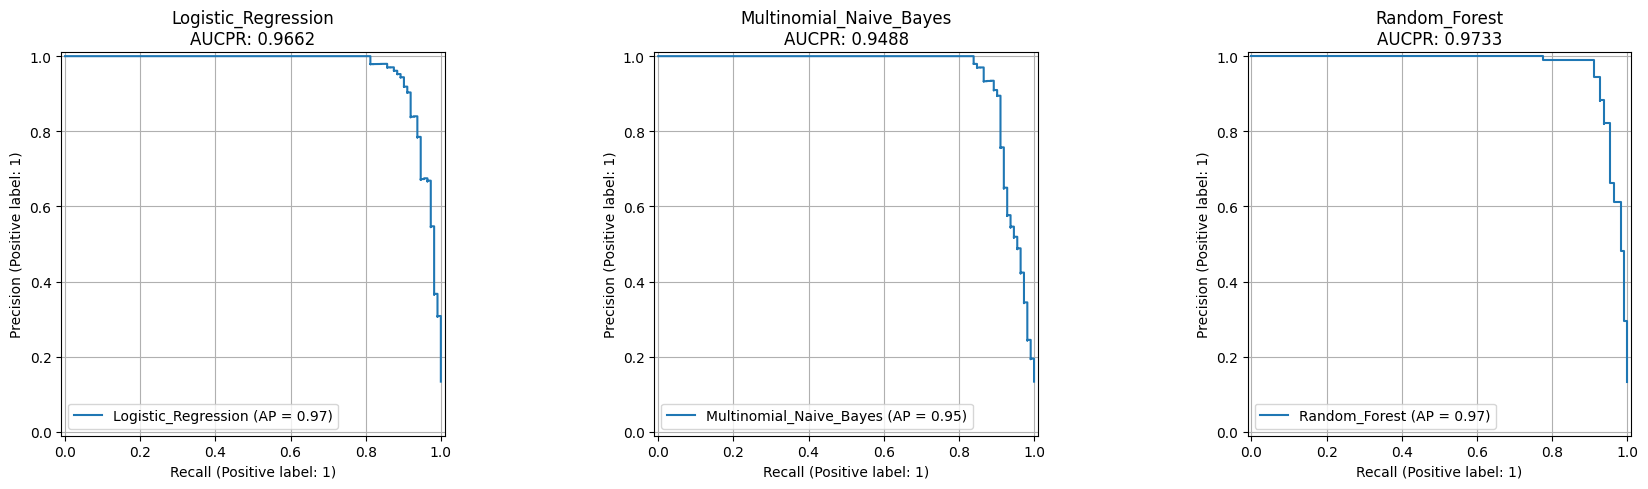

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

# Set up a subplot figure to show all models side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

# Iterate through our models - notice we use 'model_info' to represent the sub-dict
for i, (name, model_info) in enumerate(models.items()):
    # Extract the actual scikit-learn model object
    actual_model = model_info["model"]
    
    # Now pass the actual model object to the functions
    aucpr_score = get_aucpr(actual_model, X_val, y_val)
    
    display = PrecisionRecallDisplay.from_estimator(
        actual_model, X_val, y_val, ax=axes[i], name=name
    )
    
    axes[i].set_title(f"{name}\nAUCPR: {aucpr_score:.4f}")
    axes[i].grid(True)

plt.tight_layout()
plt.show()